***HOMEWORK 4***

We are going to use an employee retention dataset to do some graphing. We'll be looking at Job Satisfaction survey results.

Can we determine what is leading to employee attrition?

You can see the whole dataset here:

https://github.com/MainakRepositor/Datasets/blob/master/Employee%20Attrition.csv

**Learning Goals**
* Work with the figure and axis object
* Create basic graph types
* Continue to work on grouping/subsetting
* Try to do some more advanced graphs

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pandas.plotting import scatter_matrix
warnings.simplefilter(action='ignore', category=FutureWarning)

In [14]:
employees = pd.read_csv(
    'https://github.com/MainakRepositor/'
    'Datasets/blob/master/Employee%20Attrition.csv?raw=True'
).set_index('EmployeeNumber').drop(
    ['EmployeeCount', 'JobInvolvement', 'Gender', 'Department', 'EnvironmentSatisfaction', 'JobLevel', 'Over18','StandardHours','TrainingTimesLastYear'], axis=1)

# last6 = employees[['Attrition', 'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']]
employees.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,HourlyRate,JobRole,JobSatisfaction,...,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,
1,41,Yes,Travel_Rarely,1102,1,2,Life Sciences,94,Sales Executive,4,...,11,3,1,0,8,1,6,4,0,5
2,49,No,Travel_Frequently,279,8,1,Life Sciences,61,Research Scientist,2,...,23,4,4,1,10,3,10,7,1,7
4,37,Yes,Travel_Rarely,1373,2,2,Other,92,Laboratory Technician,3,...,15,3,2,0,7,3,0,0,0,0
5,33,No,Travel_Frequently,1392,3,4,Life Sciences,56,Research Scientist,3,...,11,3,3,0,8,3,8,7,3,0
7,27,No,Travel_Rarely,591,2,1,Medical,40,Laboratory Technician,2,...,12,3,4,1,6,3,2,2,2,2


<Axes: xlabel='JobRole'>

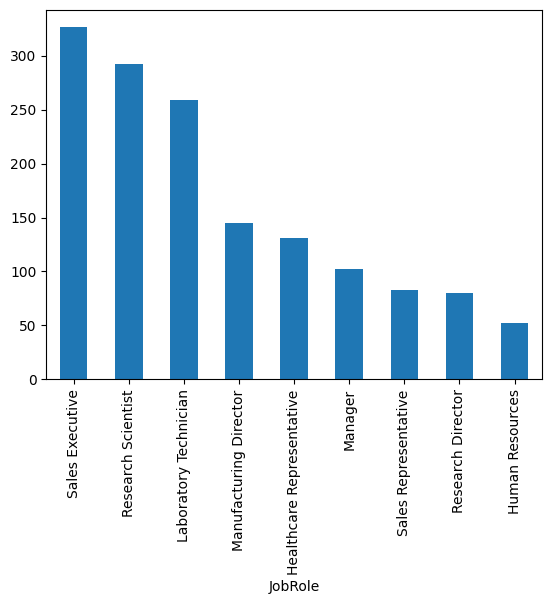

In [3]:
employees['JobRole'].value_counts().plot(kind='bar')

**CODE**

Let's do some basic graphs on our dataset

* Produce several histograms of the "Age" column, altering the bin size

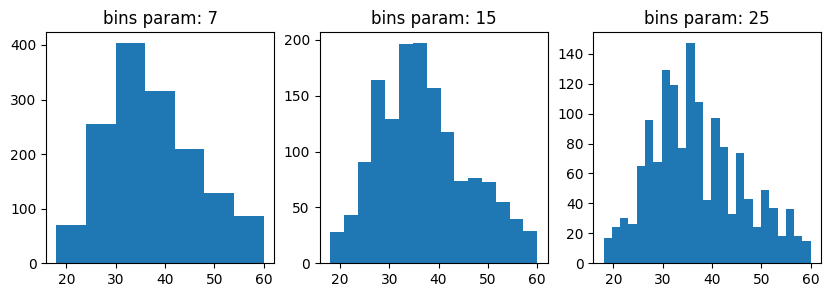

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, bins in zip(axes, [7, 15, 25]):
    ax.hist(employees.Age, bins=bins)
    ax.set_title(f'bins param: {bins}')

**CODE**

Let's work a little more with the figure and axes.

* Create a figure/axes that is 2 rows and 3 columns (OR )
* Plot histograms of the LAST 6 columns of the dataframe, which are TotalWorkingYears, WorkLifeBalance, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager
* Be sure each graph has a title of column name

**ANALYSIS**

One or two things that seem interesting or stand out from your graphs

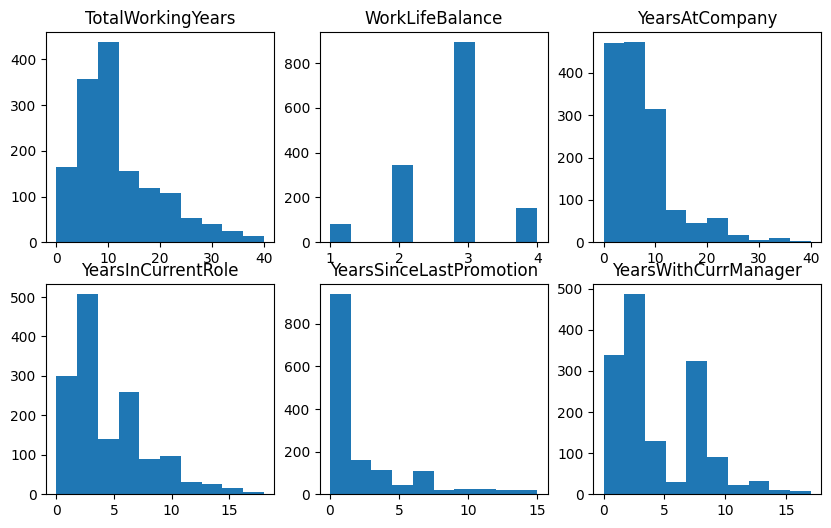

In [5]:
#create a figure that is 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

#get the lasst 6 columns of the dataframe employees
last6 = employees.iloc[:, -6:]

#plot the histogram of the last 6 columns of the dataframe employees to the given axes
for i, ax in enumerate(axes.flatten()):
    ax.hist(last6.iloc[:, i], bins=10)
    ax.set_title(last6.columns[i])


<Axes: title={'center': 'Years with Current Manager'}, ylabel='Frequency'>

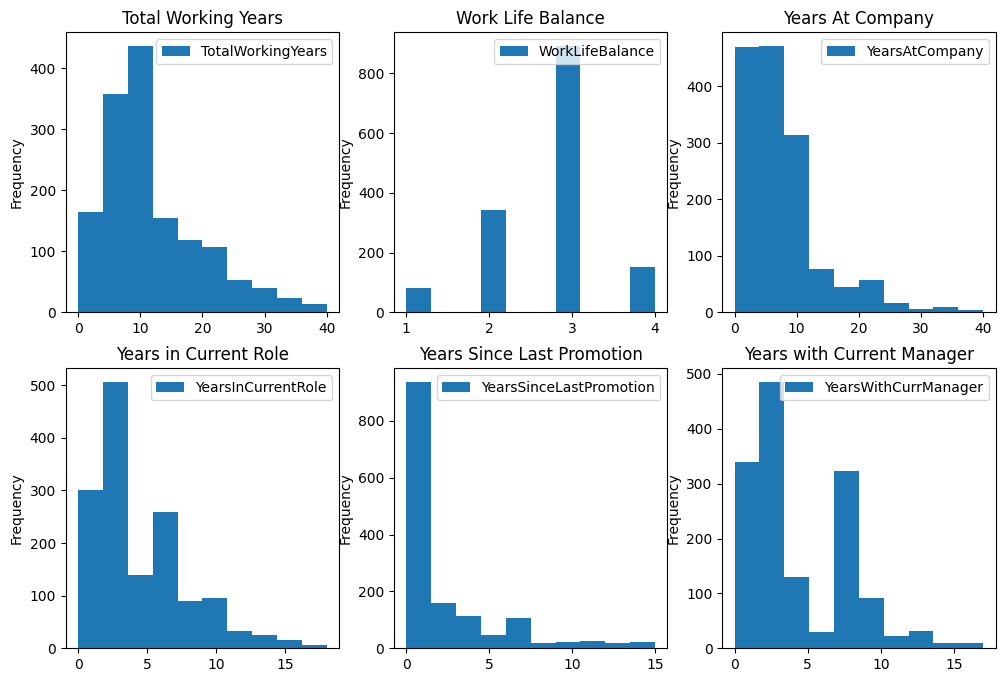

In [6]:
# ALTERNATE METHOD
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

employees[['TotalWorkingYears']].plot(ax=ax[0,0], kind='hist', title='Total Working Years')
employees[['WorkLifeBalance']].plot(ax=ax[0,1], kind='hist', title='Work Life Balance')
employees[['YearsAtCompany']].plot(ax=ax[0,2], kind='hist', title='Years At Company')
employees[['YearsInCurrentRole']].plot(ax=ax[1,0], kind='hist', title='Years in Current Role')
employees[['YearsSinceLastPromotion']].plot(ax=ax[1,1], kind='hist', title='Years Since Last Promotion')
employees[['YearsWithCurrManager']].plot(ax=ax[1,2], kind='hist', title='Years with Current Manager')

**CODE**

Get the unique count totals of the BusinessTravel column

In [7]:
#get unique values of the column BusinessTravel
print(employees.BusinessTravel.unique())
# get the counts
print(employees.BusinessTravel.value_counts())



['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64


**CODE**

Let's do a more advanced histogram. Look at the example from Chp5 Book2 that shows mag grouped by MagType

* Create a figure and axies
* For each unique value in the BusinessTravel column, create a histogram ON THE SAME AXES that shows the JobSatisfaction on the y (count) column
* Be sure to leave that "f" in front of the query specification line in the example so the query returns a float/number
* IMPORTANT: Try it as both a hist and Kernel Denstiy Estimate (kde). Not on the same graph. Separate ones.

**ANALYSIS**

Which graph (hist vs kde) do you prefer? Argue why you think your choice of graph is superior.

A: Because the distributions of the travel types are not even (Travel_Rarely - 1043 Travel_Frequently - 277 Non-Travel - 150), the KDE does a better job of showing density of each different type. The histogram showing total counts is slightly harder to interpret because the Travel_Rarely category dominates.

Text(0.5, 0, 'Job Satisfaction')

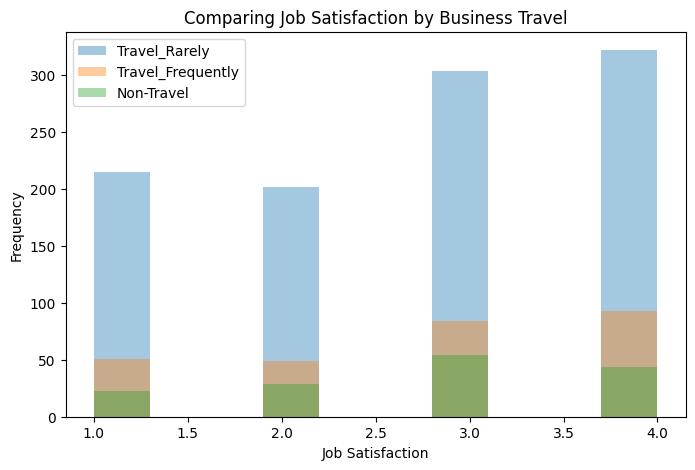

In [8]:
fig, axes = plt.subplots(figsize=(8, 5))

for travel in employees.BusinessTravel.unique():
    data = employees.query(f'BusinessTravel == "{travel}"').JobSatisfaction
    if not data.empty:
        data.plot(
            kind='hist', ax=axes, alpha=0.4, 
            label=travel, legend=True,
            title='Comparing Job Satisfaction by Business Travel'
        )

plt.xlabel('Job Satisfaction') # label the x-axis (discussed in chapter 6)

**CODE**

Let's see if we can tease any information out of the Attrition (ie they quit) column.

When generating multiple boxplots it is important to only include variables on a similar scale. For instance if you include YearsAtCompany (range of 0-40) and MonthlyRate (range of up to 30,000) you get terrible graphs.

**Grouping by Attrition yes/no**, generate some boxplots looking at the "total years" kind of data, so columns like 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'

You may need to make a large figure (I did one 10x10 with two rows and one column) to accomodate the amount of data.

**ANALYSIS**
Do any of your chosen variable appear to significantly effect Attrition? Remember we're just looking at graphs right now, no math just yet.

ANSWER: TotalWorkingYears seems to imply that younger workers were more likely to quit. Speaking generally, it appears more stability, ie longer at company, longer with manager, meant workers were less likely to quit. 

YearsSincePromotion doesnt appear to have much difference. 

/var/folders/s4/35mz08191h37fr7zq4g0m_d40000gn/T/ipykernel_39436/3167163167.py:2: UserWarning: When passing multiple axes, layout keyword is ignored.
  employees.groupby('Attrition').boxplot(
/var/folders/s4/35mz08191h37fr7zq4g0m_d40000gn/T/ipykernel_39436/3167163167.py:2: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  employees.groupby('Attrition').boxplot(


No     Axes(0.1,0.559091;0.8x0.340909)
Yes        Axes(0.1,0.15;0.8x0.340909)
dtype: object

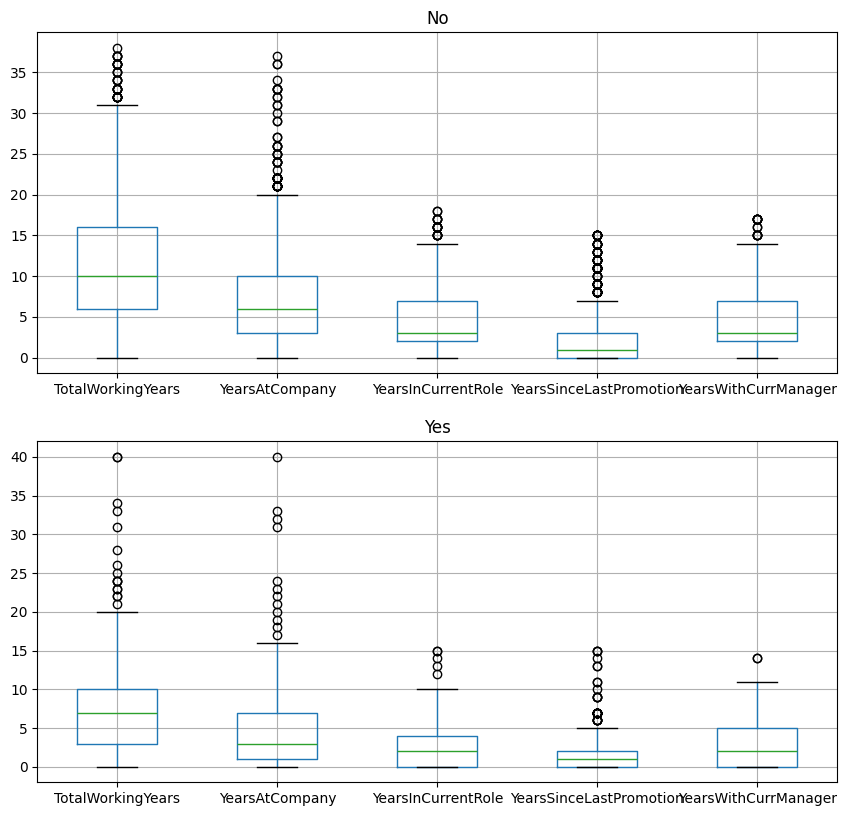

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
employees.groupby('Attrition').boxplot(
    column=['TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'],
    ax=axes, layout=(2, 1), grid=True)

/var/folders/s4/35mz08191h37fr7zq4g0m_d40000gn/T/ipykernel_39436/54263335.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_to_plot['Attrition'] = pd.Categorical(data_to_plot['Attrition'])


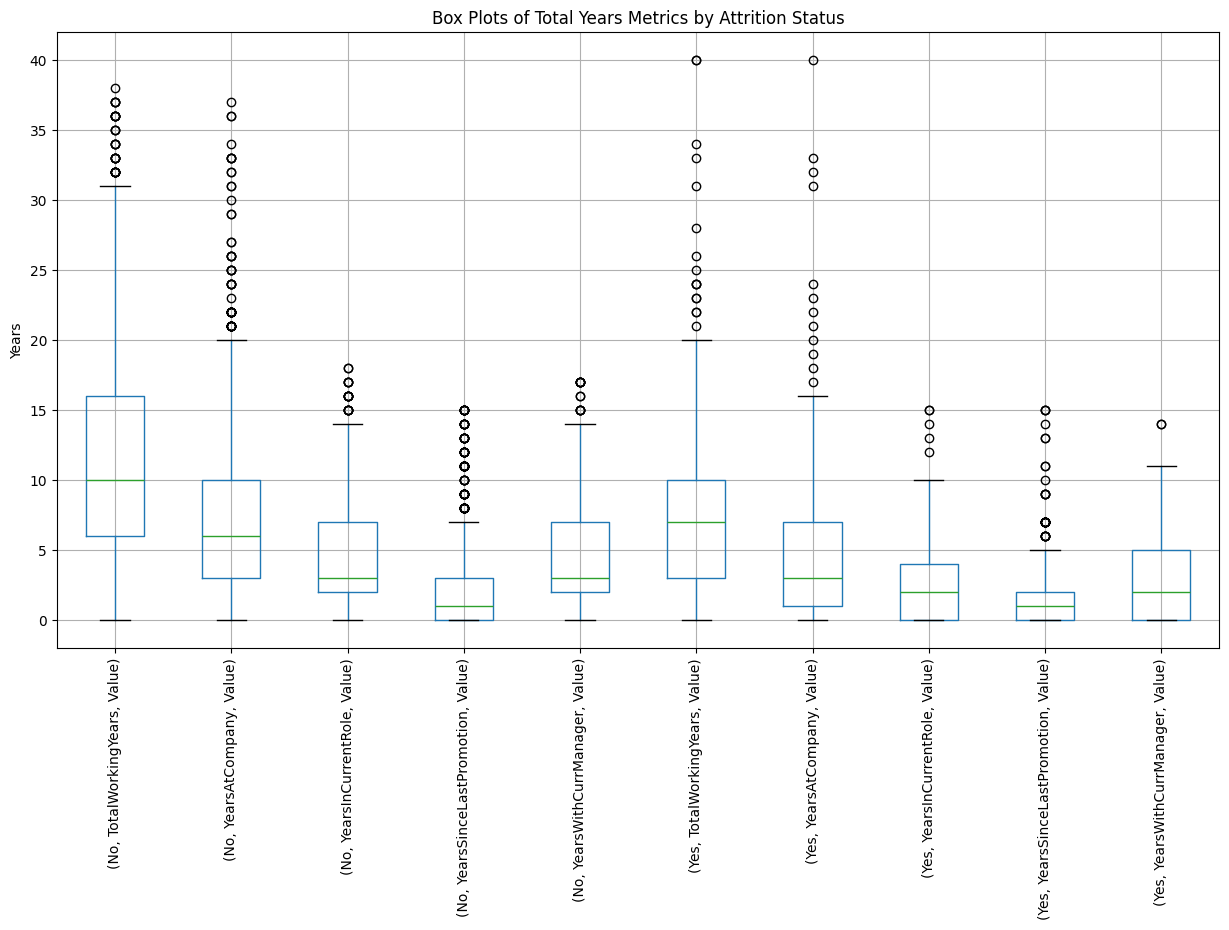

In [10]:
# ALTERNATE METHOD

columns_of_interest = ['TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

data_to_plot = employees[['Attrition'] + columns_of_interest]


data_to_plot['Attrition'] = pd.Categorical(data_to_plot['Attrition'])


melted_data = data_to_plot.melt(id_vars=['Attrition'], value_vars=columns_of_interest, var_name='YearsMetric', value_name='Value')

grouped = melted_data.groupby(['Attrition', 'YearsMetric'])
grouped.boxplot(figsize=(15, 8), subplots=False)

plt.title('Box Plots of Total Years Metrics by Attrition Status')
plt.ylabel('Years')  
plt.xticks(rotation=90)  
plt.show()

**CODE**

Let's do some scatterplots to compare the data.

Create a scatter plot:
* MonthlyRate on the x
* MontlyIncome on the y
* Color code the dots according to Attrition yes/no

**ANALYSIS**
Are there any trends on Attrition we can read from the data?

<Axes: title={'center': 'Monthly Income vs. Monthly Rate'}, xlabel='MonthlyRate', ylabel='MonthlyIncome'>

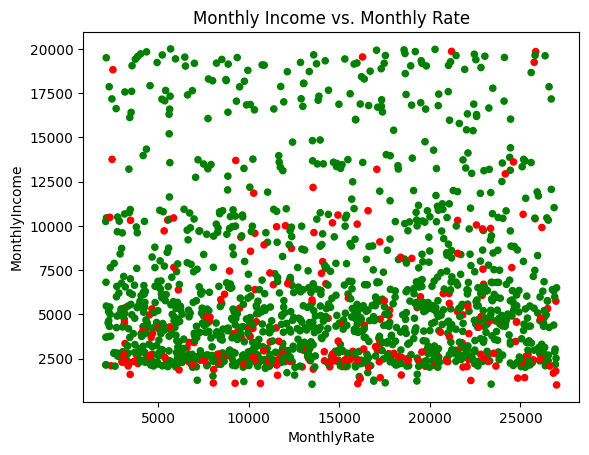

In [11]:
#create a scatter plot with MonthlyIncome and MonthlyRate
#color the points by Attrition
employees.plot(
    kind='scatter', x='MonthlyRate', y='MonthlyIncome', 
    c=employees.Attrition.map({'Yes': 'r', 'No': 'g'}),
    title='Monthly Income vs. Monthly Rate',
    legend=True
)

**CODE**

Finally lets look at the Job and Education history of people who quit.

Create a Horizontal Histogram:
* Only get records where Attrition == Yes
* Shows the count of each JobRole
* Shows it highest to lowest

Text(0.5, 1.0, 'Job Roles with the Most Attrition')

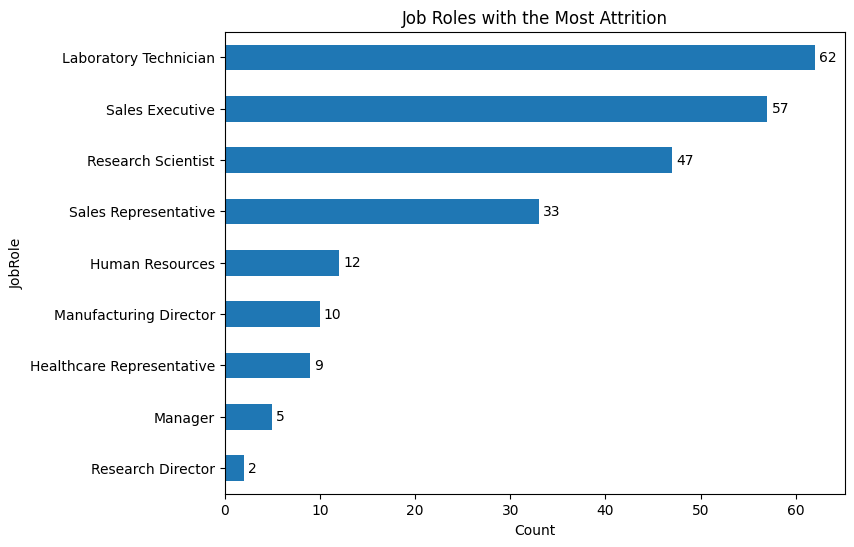

In [15]:
#create a horizontal bar plot that shows the top JobRoles by Attrition from highest to lowest

attrition_counts = employees.query('Attrition == "Yes"').JobRole.value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
attrition_counts.plot(kind='barh', ax=ax)
ax.bar_label(ax.containers[0], padding=3)
ax.set_xlabel('Count')
ax.set_title('Job Roles with the Most Attrition')
